# Experiment 4 — PSL vs Linear Scalarization: Density & Lane-Geometry Sweeps

Two systematic sweeps compare a **single PSL network** against **per-objective linear scalarization baselines**:

**Sweep A — Traffic Density** (lanes=3 fixed, vehicles ∈ {15, 30, 50})
Tests whether PSL adapts its safety-speed tradeoff to road occupancy.
Hypothesis: in *empty* roads, speed-λ activates FASTER; in *crowded*, safety-λ stays conservative.

**Sweep B — Lane Geometry** (vehicles=30 fixed, lanes ∈ {2, 3, 4})
Tests whether PSL adapts its action structure to road geometry.
Hypothesis: on 2 lanes, the safety-speed conflict is most acute — linear-speed collapses to FASTER
unsafely while PSL finds a Pareto balance. On 4 lanes, lane-weaving dominates everything.

**Comparison claim:**
> Linear scalarization perfectly optimises its target objective but collapses non-targets.
> PSL may not match the baseline on the target, but it keeps non-target objectives in check —
> giving a Pareto-balanced policy from a *single* network, adaptable at inference time.

Results accumulate in `RESULTS` (saved to `checkpoints/exp4/results.json`).
Set the `SKIP_*` flags to `True` after first run to reload checkpoints without retraining.

In [1]:
# [EXP4-01] Setup
import sys, os, glob, copy, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import numpy as np
import torch
import matplotlib.pyplot as plt
import yaml
from dataclasses import replace as dc_replace

# Patch TTC_THRESHOLD to 3 s BEFORE any env import.
# compute_safety() reads this at call time, so the patch is sufficient.
import envs.objectives as _obj
_obj.TTC_THRESHOLD = 3.0
print(f'TTC_THRESHOLD patched to {_obj.TTC_THRESHOLD} s')

from envs import MOHighwayEnv
from models.policy import ConditionedPolicy
from training.psl_trainer import PSLTrainer, PSLConfig
from baselines.scalarized_trainer import PRESETS, train as train_baseline

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)
pc = config['policy']

RESULTS = {}   # {sweep: {condition: {psl: {...}, baseline: {...}}}}

print('All imports OK.  Policy config:', pc)

TTC_THRESHOLD patched to 3.0 s
All imports OK.  Policy config: {'obs_dim': 25, 'lam_dim': 3, 'hidden_dim': 128, 'n_actions': 5}


objc[86696]: Class SDLApplication is implemented in both /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1694a52c8) and /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x17eb14890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[86696]: Class SDLAppDelegate is implemented in both /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1694a5318) and /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x17eb148e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[86696]: Class SDLTranslatorResponder is implemented in both /Users/Ravi

In [ ]:
# [EXP4-02] Sweep configurations

BASE_ENV = {'duration': 25, 'policy_frequency': 2, 'simulation_frequency': 15}

# Sweep A: fix lanes=3, vary traffic density
SWEEP_A = {
    'empty':   {**BASE_ENV, 'lanes_count': 3, 'vehicles_count': 15},
    'normal':  {**BASE_ENV, 'lanes_count': 3, 'vehicles_count': 30},
    'crowded': {**BASE_ENV, 'lanes_count': 3, 'vehicles_count': 50},
}

# Sweep B: fix vehicles=30, vary lane count
SWEEP_B = {
    '2_lanes': {**BASE_ENV, 'lanes_count': 2, 'vehicles_count': 30},
    '3_lanes': {**BASE_ENV, 'lanes_count': 3, 'vehicles_count': 30},
    '4_lanes': {**BASE_ENV, 'lanes_count': 4, 'vehicles_count': 30},
}

# PSL hyperparameters (shared across all conditions)
# n_updates raised to 150: more training needed for λ-conditioned costs to
# order correctly (safety-λ → lowest f_safety, etc.)
PSL_CFG = PSLConfig(
    n_pref_samples      = 12,
    n_episodes_per_pref = 10,
    n_updates           = 150,
    gamma               = 0.99,
    learning_rate       = 3e-4,
    critic_lr           = 1e-3,
    entropy_coef        = 0.05,
    p_corner            = 0.4,
    grad_clip           = 0.5,
    log_interval        = 10,
    save_interval       = 25,
    seed                = 42,
    n_workers           = 11,
)

BASELINE_N_EPISODES = 300
# comfort added: tests that PSL@comfort-λ achieves lowest f_comfort
# while baseline-comfort collapses speed and safety
BASELINE_PRESETS    = ['safety', 'speed', 'comfort', 'uniform']
N_EVAL              = 15   # episodes per lambda at evaluation

# Near-corner lambdas for PSL (avoid exact zeros — EPO's LP uses 1/lambda internally)
PSL_EVAL_LAMS = {
    'safety':  np.array([0.90, 0.05, 0.05], dtype=np.float32),
    'speed':   np.array([0.05, 0.90, 0.05], dtype=np.float32),
    'comfort': np.array([0.05, 0.05, 0.90], dtype=np.float32),
    'uniform': np.array([1/3,  1/3,  1/3],  dtype=np.float32),
}
# Baselines evaluated at their exact training lambda
BASELINE_EVAL_LAMS = {p: PRESETS[p] for p in BASELINE_PRESETS}

ACTION_NAMES = ['LANE_LEFT', 'IDLE', 'LANE_RIGHT', 'FASTER', 'SLOWER']
OBJ_NAMES    = ['f_safety', 'f_speed', 'f_comfort']
OBJ_COLORS   = ['#d62728', '#1f77b4', '#2ca02c']

total_psl = PSL_CFG.n_pref_samples * PSL_CFG.n_episodes_per_pref * PSL_CFG.n_updates
print(f'PSL episodes per run : {total_psl:,}  (6 runs = {6*total_psl:,} total)')
print(f'Baseline eps per run : {BASELINE_N_EPISODES}  (24 runs = {24*BASELINE_N_EPISODES:,} total)')
print()
for sweep_name, sweep in [('A (density)', SWEEP_A), ('B (lanes)', SWEEP_B)]:
    for cond, cfg in sweep.items():
        print(f'  Sweep {sweep_name}  {cond:10s}: L={cfg["lanes_count"]} V={cfg["vehicles_count"]}')

PSL episodes per run : 18,000  (6 runs = 108,000 total)
Baseline eps per run : 600  (24 runs = 14,400 total)

  Sweep A (density)  empty     : L=3 V=15
  Sweep A (density)  normal    : L=3 V=30
  Sweep A (density)  crowded   : L=3 V=50
  Sweep B (lanes)  2_lanes   : L=2 V=30
  Sweep B (lanes)  3_lanes   : L=3 V=30
  Sweep B (lanes)  4_lanes   : L=4 V=30


In [ ]:
# [EXP4-03] Shared helper functions

# ── Checkpoint paths ─────────────────────────────────────────────────────────
def psl_ckpt_dir(sweep_label, condition):
    return f'checkpoints/exp4/{sweep_label}/psl_{condition}'

def baseline_ckpt(sweep_label, condition, preset):
    return f'checkpoints/exp4/{sweep_label}/baseline_{condition}/{preset}/ep{BASELINE_N_EPISODES:05d}.pt'

# ── Loading ───────────────────────────────────────────────────────────────────
def load_latest_psl(ckpt_dir, env_cfg):
    '''Load the most recent PSL checkpoint into an eval-only trainer (no worker pool).'''
    trainer = PSLTrainer(dc_replace(PSL_CFG, n_workers=1), env_config=env_cfg, policy_config=pc)
    ckpts   = sorted(glob.glob(os.path.join(ckpt_dir, 'psl_upd*.pt')))
    if ckpts:
        trainer.load(ckpts[-1])
        print(f'    loaded {os.path.basename(ckpts[-1])}')
    else:
        print(f'    WARNING: no checkpoint in {ckpt_dir}')
    return trainer

def load_baseline_policy(ckpt_path):
    if not os.path.exists(ckpt_path):
        print(f'    WARNING: {ckpt_path} not found')
        return None
    saved = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    pol   = ConditionedPolicy(**pc)
    pol.load_state_dict(saved['policy_state_dict'])
    pol.eval()
    return pol

# ── Training sweeps ───────────────────────────────────────────────────────────
def run_psl_sweep(sweep_label, sweep_cfgs, skip=False):
    '''Train or load PSL for all conditions. Returns {condition: PSLTrainer}.'''
    trainers = {}
    for condition, env_cfg in sweep_cfgs.items():
        ckpt_dir = psl_ckpt_dir(sweep_label, condition)
        os.makedirs(ckpt_dir, exist_ok=True)
        if skip:
            print(f'  Loading PSL {sweep_label}/{condition}')
            trainers[condition] = load_latest_psl(ckpt_dir, env_cfg)
        else:
            print(f'\n{"="*55}')
            vcount = env_cfg['vehicles_count']
            lcount = env_cfg['lanes_count']
            print(f'  Training PSL  sweep={sweep_label}  cond={condition}  L={lcount} V={vcount}')
            print(f'{"="*55}')
            trainer = PSLTrainer(dc_replace(PSL_CFG, checkpoint_dir=ckpt_dir),
                                 env_config=env_cfg, policy_config=pc)
            trainer.train()
            trainer.close()
            trainers[condition] = load_latest_psl(ckpt_dir, env_cfg)
    return trainers

def _train_one_baseline(args):
    sweep_label, condition, env_cfg, preset, baseline_n_eps = args
    import os, sys, yaml
    sys.path.insert(0, '.')
    from baselines.scalarized_trainer import train as _train
    with open('configs/default.yaml') as f:
        cfg = yaml.safe_load(f)
    cfg['env'].update(env_cfg)
    ckpt_dir = f'checkpoints/exp4/{sweep_label}/baseline_{condition}'
    _train(lam_name=preset, cfg=cfg, checkpoint_dir=ckpt_dir,
           n_episodes_override=baseline_n_eps, log_interval_override=100)

def run_baseline_sweep(sweep_label, sweep_cfgs, skip=False):
    from concurrent.futures import ProcessPoolExecutor, as_completed
    policies = {}
    for condition, env_cfg in sweep_cfgs.items():
        to_train = []
        for preset in BASELINE_PRESETS:
            if skip and os.path.exists(baseline_ckpt(sweep_label, condition, preset)):
                print(f'  skip  {sweep_label}/{condition}/{preset}')
            else:
                to_train.append(preset)
        if to_train:
            lcount = env_cfg['lanes_count']; vcount = env_cfg['vehicles_count']
            print(f'\n  Baselines {sweep_label}/{condition} (L={lcount} V={vcount}): '
                  f'training {to_train} in parallel...')
            args_list = [(sweep_label, condition, env_cfg, p, BASELINE_N_EPISODES)
                         for p in to_train]
            with ProcessPoolExecutor(max_workers=len(to_train)) as ex:
                futs = {ex.submit(_train_one_baseline, a): a[3] for a in args_list}
                for fut in as_completed(futs):
                    preset_done = futs[fut]
                    try:
                        fut.result()
                        print(f'    done: {preset_done}')
                    except Exception as e:
                        print(f'    ERROR {preset_done}: {e}')
        for preset in BASELINE_PRESETS:
            pol = load_baseline_policy(baseline_ckpt(sweep_label, condition, preset))
            if pol is not None:
                policies[(condition, preset)] = pol
    return policies


# ── Evaluation ────────────────────────────────────────────────────────────────
def eval_policy(policy, env_cfg, eval_lams, n_episodes=N_EVAL, greedy=True):
    '''
    Evaluate a policy at each lambda in eval_lams (greedy by default).
    Returns {lam_label: {dominant_action, action_freqs, costs}}.
    '''
    out = {}
    for lam_label, lam in eval_lams.items():
        lam_t   = torch.tensor(lam, dtype=torch.float32)
        counts  = np.zeros(5)
        total   = 0
        ep_cost_list = []
        env = MOHighwayEnv(config=env_cfg)
        with torch.no_grad():
            for _ in range(n_episodes):
                obs, _ = env.reset()
                done   = False
                step_costs = []
                while not done:
                    obs_t  = torch.tensor(obs.flatten(), dtype=torch.float32)
                    logits = policy(obs_t, lam_t)
                    action = int(logits.argmax().item()) if greedy else                              int(torch.distributions.Categorical(logits=logits).sample().item())
                    obs, cost_vec, term, trunc, _ = env.step(action)
                    counts[action] += 1
                    total          += 1
                    step_costs.append(np.array(cost_vec, dtype=np.float32))
                    done = term or trunc
                ep_cost_list.append(np.mean(step_costs, axis=0))
        env.close()
        freqs = counts / max(total, 1)
        out[lam_label] = {
            'dominant_action': ACTION_NAMES[int(np.argmax(freqs))],
            'action_freqs':    freqs.tolist(),
            'costs':           np.mean(ep_cost_list, axis=0).tolist(),
        }
    return out

def eval_sweep(sweep_label, psl_trainers, baseline_policies, sweep_cfgs):
    '''Evaluate all policies in a sweep and update the global RESULTS dict.'''
    for condition, env_cfg in sweep_cfgs.items():
        print(f'\nEvaluating {sweep_label}/{condition} ...')
        # PSL at all eval lambdas
        if condition in psl_trainers:
            res = eval_policy(psl_trainers[condition].policy, env_cfg, PSL_EVAL_LAMS)
            for lam_label, ed in res.items():
                c = ed['costs']
                RESULTS.setdefault(sweep_label, {}).setdefault(condition, {'psl': {}, 'baseline': {}})
                RESULTS[sweep_label][condition]['psl'][lam_label] = ed
                print(f'  PSL  @{lam_label:8s}: {ed["dominant_action"]:10s} '
                      f'saf={c[0]:.3f} spd={c[1]:.3f} com={c[2]:.3f}')
        # Each baseline at its own training lambda
        for preset in BASELINE_PRESETS:
            key = (condition, preset)
            if key in baseline_policies:
                res = eval_policy(baseline_policies[key], env_cfg,
                                  {preset: BASELINE_EVAL_LAMS[preset]})
                ed  = res[preset]
                c   = ed['costs']
                RESULTS.setdefault(sweep_label, {}).setdefault(condition, {'psl': {}, 'baseline': {}})
                RESULTS[sweep_label][condition]['baseline'][preset] = ed
                print(f'  Base @{preset:8s}: {ed["dominant_action"]:10s} '
                      f'saf={c[0]:.3f} spd={c[1]:.3f} com={c[2]:.3f}')

# ── Results persistence ────────────────────────────────────────────────────────
def save_results():
    path = 'checkpoints/exp4/results.json'
    os.makedirs('checkpoints/exp4', exist_ok=True)
    with open(path, 'w') as f:
        json.dump(RESULTS, f, indent=2)
    print(f'Results saved → {path}')

def load_results():
    path = 'checkpoints/exp4/results.json'
    if os.path.exists(path):
        with open(path) as f:
            RESULTS.update(json.load(f))
        print(f'Results loaded from {path}')
    else:
        print('No saved results found.')

# ── Formatted table ────────────────────────────────────────────────────────────
def print_table(sweep_label):
    if sweep_label not in RESULTS:
        print(f'No results for sweep "{sweep_label}"'); return
    hdr = f'  {"Condition":10s} {"Policy":22s} {"Pref":8s} {"f_safety":8s} {"f_speed":7s} {"f_comfort":9s} Dominant'
    sep = '  ' + '-' * (len(hdr) - 2)
    print(f'\n{"="*(len(hdr))}')
    print(f'  Sweep: {sweep_label}')
    print(hdr); print(sep)
    for condition, cdata in RESULTS[sweep_label].items():
        for lam_label, ed in cdata.get('psl', {}).items():
            c = ed['costs']
            print(f'  {condition:10s} {"PSL":22s} {lam_label:8s} {c[0]:8.3f} {c[1]:7.3f} {c[2]:9.3f} {ed["dominant_action"]}')
        for preset, ed in cdata.get('baseline', {}).items():
            c = ed['costs']
            print(f'  {condition:10s} {("Baseline-"+preset):22s} {preset:8s} {c[0]:8.3f} {c[1]:7.3f} {c[2]:9.3f} {ed["dominant_action"]}')
        print(sep)

print('Helper functions defined.')

Helper functions defined.


---
## Sweep A — Traffic Density  (lanes=3, vehicles ∈ {15, 30, 50})

**What we expect to see:**
- **empty (15 vehicles):** Clear road ahead. Speed-λ should be able to activate FASTER safely.
  Linear speed-baseline will also use FASTER but may be reckless (ignores safety cost).
  PSL speed-λ should match speed performance while keeping safety cost lower.
- **normal (30 vehicles):** Moderate traffic. Some λ-differentiation expected.
- **crowded (50 vehicles):** Dense traffic. Safety gradient dominates.
  Policy may collapse to IDLE/SLOWER for all λ — the front narrows.

**Set `SKIP_PSL_A = True` and `SKIP_BASE_A = True` after the first run.**

In [4]:
# [EXP4-A1] Train PSL — Sweep A (density)
SKIP_PSL_A = False   # set True after first run to reload from checkpoint

psl_A = run_psl_sweep('density', SWEEP_A, skip=SKIP_PSL_A)
print('\nSweep A PSL training done.')


  Training PSL  sweep=density  cond=empty  L=3 V=15
PSL upd  10/150  G=[s=0.445 v=0.094 c=0.434]  α=[0.62 0.17 0.21]  L_pol=[-1.626 +4.614 -0.638]  L_crit=7.3190
PSL upd  20/150  G=[s=0.444 v=0.103 c=0.460]  α=[0.67 0.00 0.33]  L_pol=[+2.039 +5.512 +1.141]  L_crit=5.1123
PSL upd  30/150  G=[s=0.445 v=0.097 c=0.454]  α=[0.33 0.24 0.43]  L_pol=[+0.844 +3.310 +1.229]  L_crit=4.9588
PSL upd  40/150  G=[s=0.427 v=0.106 c=0.440]  α=[0.42 0.17 0.42]  L_pol=[+1.030 +3.568 +2.257]  L_crit=4.6132
PSL upd  50/150  G=[s=0.454 v=0.090 c=0.400]  α=[0.58 0.08 0.34]  L_pol=[+0.890 +3.738 +2.885]  L_crit=4.5120
PSL upd  60/150  G=[s=0.469 v=0.081 c=0.402]  α=[0.69 0.17 0.14]  L_pol=[+0.588 +3.065 +0.607]  L_crit=4.5400
PSL upd  70/150  G=[s=0.473 v=0.077 c=0.409]  α=[0.33 0.25 0.42]  L_pol=[+0.628 +5.638 +1.448]  L_crit=4.1783
PSL upd  80/150  G=[s=0.451 v=0.093 c=0.426]  α=[0.67 0.08 0.25]  L_pol=[+0.655 +5.900 +1.206]  L_crit=3.1253
PSL upd  90/150  G=[s=0.449 v=0.091 c=0.400]  α=[0.42 0.08 0.50]  L

In [5]:
# [EXP4-A2] Train baselines — Sweep A (density)
SKIP_BASE_A = False   # set True after first run

base_A = run_baseline_sweep('density', SWEEP_A, skip=SKIP_BASE_A)
print('\nSweep A baseline training done.')


  Baseline  sweep=density  cond=empty  preset=safety  L=3 V=15
[safety] ep   100/600  G_safety=2.241  G_speed=0.426  G_comfort=2.918  T=  4  L_pol=1.95302  L_crit=1.86176  ETA 0m 44s
  → saved checkpoints/exp4/density/baseline_empty/safety/ep00100.pt
[safety] ep   200/600  G_safety=3.922  G_speed=0.431  G_comfort=3.255  T=  7  L_pol=0.44404  L_crit=0.97659  ETA 0m 32s
  → saved checkpoints/exp4/density/baseline_empty/safety/ep00200.pt
[safety] ep   300/600  G_safety=2.348  G_speed=0.501  G_comfort=1.960  T=  4  L_pol=0.87829  L_crit=0.51844  ETA 0m 23s
  → saved checkpoints/exp4/density/baseline_empty/safety/ep00300.pt
[safety] ep   400/600  G_safety=2.783  G_speed=0.616  G_comfort=2.670  T=  6  L_pol=0.06037  L_crit=3.69217  ETA 0m 15s
  → saved checkpoints/exp4/density/baseline_empty/safety/ep00400.pt
[safety] ep   500/600  G_safety=3.886  G_speed=1.324  G_comfort=5.848  T=  9  L_pol=0.12809  L_crit=0.92517  ETA 0m 07s
  → saved checkpoints/exp4/density/baseline_empty/safety/ep00500

In [6]:
# [EXP4-A3] Evaluate Sweep A and print results table
eval_sweep('density', psl_A, base_A, SWEEP_A)
save_results()
print_table('density')


Evaluating density/empty ...
  PSL  @safety  : LANE_LEFT  saf=0.500 spd=0.184 com=0.317
  PSL  @speed   : FASTER     saf=0.509 spd=0.024 com=0.152
  PSL  @comfort : IDLE       saf=0.393 spd=0.175 com=0.023
  PSL  @uniform : IDLE       saf=0.411 spd=0.175 com=0.027
  Base @safety  : FASTER     saf=0.514 spd=0.026 com=0.135
  Base @speed   : FASTER     saf=0.524 spd=0.031 com=0.146
  Base @comfort : IDLE       saf=0.407 spd=0.174 com=0.021
  Base @uniform : FASTER     saf=0.512 spd=0.025 com=0.141

Evaluating density/normal ...
  PSL  @safety  : LANE_RIGHT saf=0.388 spd=0.175 com=0.079
  PSL  @speed   : FASTER     saf=0.494 spd=0.028 com=0.151
  PSL  @comfort : FASTER     saf=0.490 spd=0.022 com=0.134
  PSL  @uniform : LANE_RIGHT saf=0.359 spd=0.175 com=0.104
  Base @safety  : LANE_LEFT  saf=0.393 spd=0.177 com=0.082
  Base @speed   : FASTER     saf=0.513 spd=0.026 com=0.149
  Base @comfort : IDLE       saf=0.402 spd=0.172 com=0.021
  Base @uniform : FASTER     saf=0.526 spd=0.027 com=0

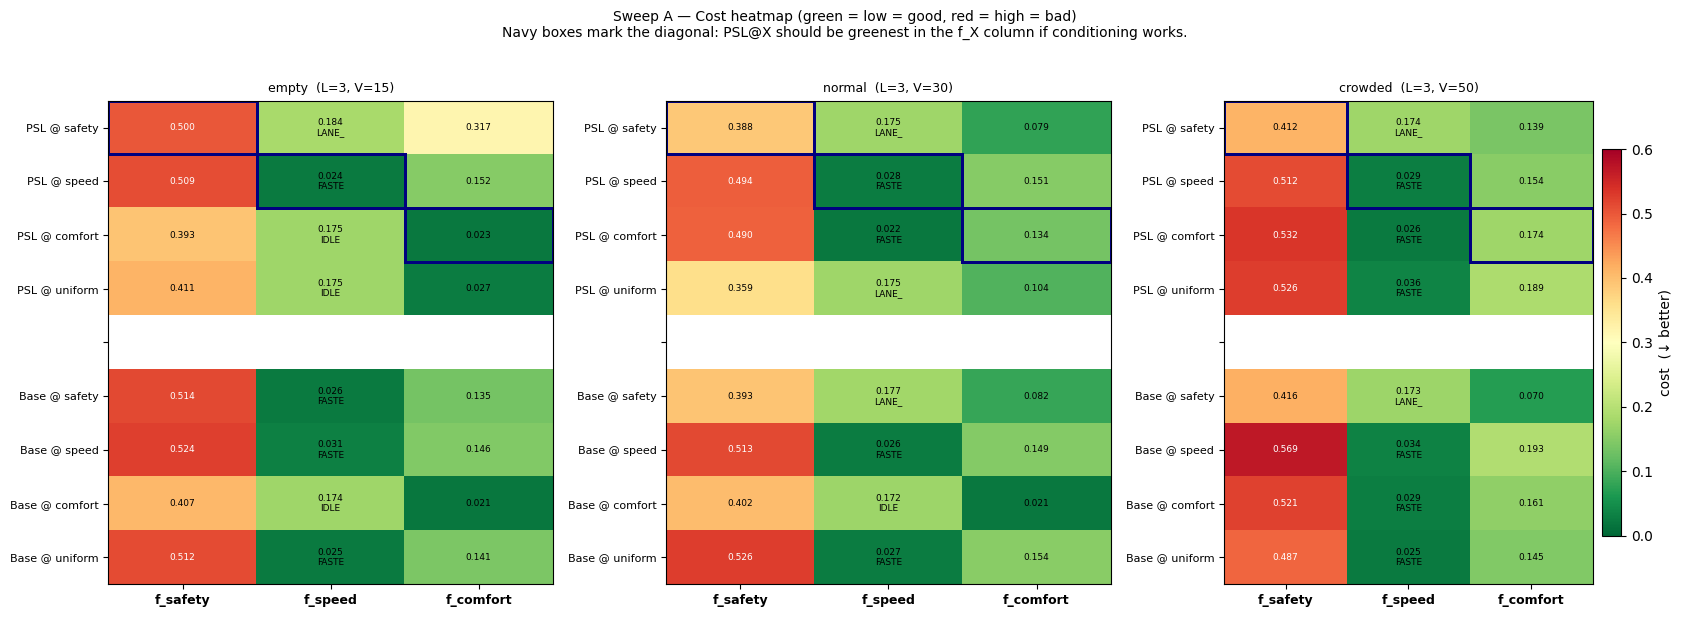

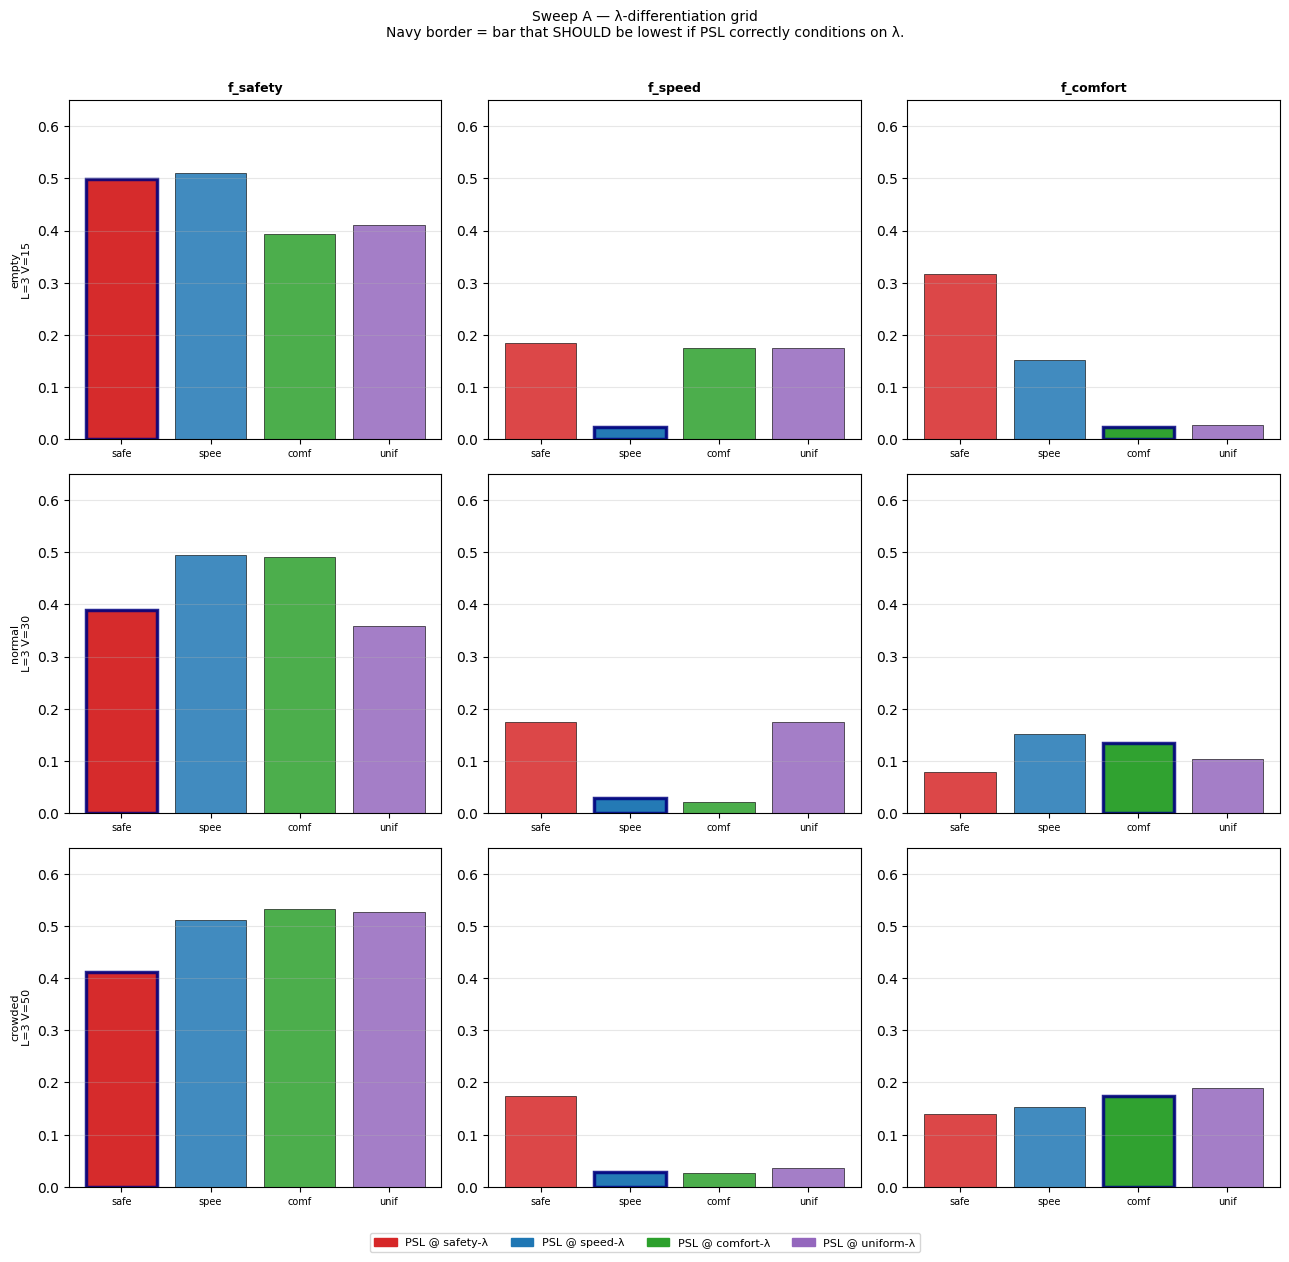

In [8]:
# [EXP4-A4] Visualise Sweep A results

import matplotlib.colors as mcolors
from matplotlib.patches import Patch

SWEEP_LABEL = 'density'
SWEEP_CFGS  = SWEEP_A
conditions  = list(SWEEP_CFGS.keys())
psl_prefs   = list(PSL_EVAL_LAMS.keys())   # safety, speed, comfort, uniform

# ── Chart 1: Heatmap — all policies × objectives per condition ────────────────
# Each row = one policy; each column = one objective.
# Green = low cost (good), red = high cost (bad).
# The diagonal expectation: PSL@safety row should be greenest in f_safety column,
# PSL@speed row greenest in f_speed column, PSL@comfort row greenest in f_comfort column.

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, condition in zip(axes, conditions):
    cdata = RESULTS.get(SWEEP_LABEL, {}).get(condition, {})

    row_labels, cost_matrix, dom_actions = [], [], []
    for pref in psl_prefs:
        ed = cdata.get('psl', {}).get(pref)
        if ed:
            row_labels.append(f'PSL @ {pref}')
            cost_matrix.append(ed['costs'])
            dom_actions.append(ed['dominant_action'])

    row_labels.append('')          # blank separator row
    cost_matrix.append([np.nan]*3)
    dom_actions.append('')

    for preset in BASELINE_PRESETS:
        ed = cdata.get('baseline', {}).get(preset)
        if ed:
            row_labels.append(f'Base @ {preset}')
            cost_matrix.append(ed['costs'])
            dom_actions.append(ed['dominant_action'])

    mat = np.array(cost_matrix, dtype=float)

    im = ax.imshow(mat, cmap='RdYlGn_r', vmin=0.0, vmax=0.6, aspect='auto')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(OBJ_NAMES, fontsize=9, fontweight='bold')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)

    # Annotate cells with value + dominant action (action only on f_speed column)
    for ri, (row_costs, action) in enumerate(zip(cost_matrix, dom_actions)):
        for ci, cost in enumerate(row_costs):
            if not np.isnan(cost):
                txt = f'{cost:.3f}'
                if ci == 1 and action:   # show action under f_speed column
                    txt += f'\n{action[:5]}'
                colour = 'white' if cost > 0.42 else 'black'
                ax.text(ci, ri, txt, ha='center', va='center',
                        fontsize=6.5, color=colour)

    env_cfg = SWEEP_CFGS[condition]
    ax.set_title(f'{condition}  (L={env_cfg["lanes_count"]}, V={env_cfg["vehicles_count"]})',
                 fontsize=9, pad=6)

    # Highlight the "diagonal" cells: PSL@X should be best at f_X
    diag_map = {'safety': 0, 'speed': 1, 'comfort': 2}
    for pi, pref in enumerate(psl_prefs):
        if pref not in diag_map:
            continue
        col = diag_map[pref]
        for spine_loc in ['top','bottom','left','right']:
            rect = plt.Rectangle((col-0.5, pi-0.5), 1, 1,
                                  linewidth=2, edgecolor='navy', facecolor='none')
            ax.add_patch(rect)

plt.colorbar(im, ax=axes[-1], label='cost  (↓ better)', shrink=0.8, pad=0.02)
plt.suptitle(
    'Sweep A — Cost heatmap (green = low = good, red = high = bad)\n'
    'Navy boxes mark the diagonal: PSL@X should be greenest in the f_X column if conditioning works.',
    fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('checkpoints/exp4/sweep_A_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart 2: λ-differentiation grid — row=condition, col=objective ────────────
# Each cell: 4 bars (one per PSL preference).
# Correct PSL behaviour: in column f_X, the bar for preference X should be lowest.

fig2, axes2 = plt.subplots(len(conditions), 3, figsize=(13, 4*len(conditions)),
                            sharey=False)
pref_colors = {'safety': '#d62728', 'speed': '#1f77b4',
               'comfort': '#2ca02c', 'uniform': '#9467bd'}

for ri, condition in enumerate(conditions):
    cdata = RESULTS.get(SWEEP_LABEL, {}).get(condition, {})
    for ci, obj_name in enumerate(OBJ_NAMES):
        ax = axes2[ri, ci]
        vals, colors, labels = [], [], []
        for pref in psl_prefs:
            ed = cdata.get('psl', {}).get(pref)
            vals.append(ed['costs'][ci] if ed else 0)
            colors.append(pref_colors[pref])
            labels.append(pref)

        xs = np.arange(len(psl_prefs))
        bars = ax.bar(xs, vals, color=colors, alpha=0.85, edgecolor='k', linewidth=0.5)

        # Star the bar that SHOULD be lowest
        expected_best = ci  # safety=0, speed=1, comfort=2, uniform=3
        if expected_best < len(psl_prefs):
            ax.bar(expected_best, vals[expected_best], color=colors[expected_best],
                   alpha=0.85, edgecolor='navy', linewidth=2.5)

        ax.set_xticks(xs)
        ax.set_xticklabels([p[:4] for p in labels], fontsize=7)
        ax.set_ylim(0, 0.65)
        ax.grid(alpha=0.3, axis='y')

        if ci == 0:
            env_cfg = SWEEP_CFGS[condition]
            ax.set_ylabel(f'{condition}\nL={env_cfg["lanes_count"]} V={env_cfg["vehicles_count"]}',
                          fontsize=8)
        if ri == 0:
            ax.set_title(obj_name, fontsize=9, fontweight='bold')

legend_handles = [Patch(color=pref_colors[p], label=f'PSL @ {p}-λ') for p in psl_prefs]
fig2.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))
plt.suptitle(
    'Sweep A — λ-differentiation grid\n'
    'Navy border = bar that SHOULD be lowest if PSL correctly conditions on λ.',
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('checkpoints/exp4/sweep_A_lam_grid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sweep B — Lane Geometry  (vehicles=30, lanes ∈ {2, 3, 4})

**What we expect to see:**
- **2 lanes:** Lateral maneuvers are costly — only one escape direction, and the wall/adjacent lane is
  right there. FASTER vs. IDLE/SLOWER becomes the primary tradeoff. The safety-speed conflict is most
  severe here. Linear speed-baseline learns FASTER even when unsafe → high speed, more crashes.
  PSL speed-λ learns FASTER but with residual safety awareness.
- **3 lanes:** Balanced. Both lateral and longitudinal strategies viable.
- **4 lanes:** Lane changes are cheap. Lane-weaving dominates all objectives (confirmed in Exp 2).
  Expect LANE_LEFT for all preferences regardless of λ → flat Pareto front → hardest case for PSL.

**Set `SKIP_PSL_B = True` and `SKIP_BASE_B = True` after the first run.**

In [ ]:
# [EXP4-B1] Train PSL — Sweep B (lane geometry)
SKIP_PSL_B = False   # set True after first run

psl_B = run_psl_sweep('lanes', SWEEP_B, skip=SKIP_PSL_B)
print('\nSweep B PSL training done.')

In [ ]:
# [EXP4-B2] Train baselines — Sweep B (lane geometry)
SKIP_BASE_B = False   # set True after first run

base_B = run_baseline_sweep('lanes', SWEEP_B, skip=SKIP_BASE_B)
print('\nSweep B baseline training done.')

In [ ]:
# [EXP4-B3] Evaluate Sweep B and print results table
eval_sweep('lanes', psl_B, base_B, SWEEP_B)
save_results()
print_table('lanes')

In [ ]:
# [EXP4-B4] Visualise Sweep A results

import matplotlib.colors as mcolors
from matplotlib.patches import Patch

SWEEP_LABEL = 'lanes'
SWEEP_CFGS  = SWEEP_B
conditions  = list(SWEEP_CFGS.keys())
psl_prefs   = list(PSL_EVAL_LAMS.keys())   # safety, speed, comfort, uniform

# ── Chart 1: Heatmap — all policies × objectives per condition ────────────────
# Each row = one policy; each column = one objective.
# Green = low cost (good), red = high cost (bad).
# The diagonal expectation: PSL@safety row should be greenest in f_safety column,
# PSL@speed row greenest in f_speed column, PSL@comfort row greenest in f_comfort column.

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, condition in zip(axes, conditions):
    cdata = RESULTS.get(SWEEP_LABEL, {}).get(condition, {})

    row_labels, cost_matrix, dom_actions = [], [], []
    for pref in psl_prefs:
        ed = cdata.get('psl', {}).get(pref)
        if ed:
            row_labels.append(f'PSL @ {pref}')
            cost_matrix.append(ed['costs'])
            dom_actions.append(ed['dominant_action'])

    row_labels.append('')          # blank separator row
    cost_matrix.append([np.nan]*3)
    dom_actions.append('')

    for preset in BASELINE_PRESETS:
        ed = cdata.get('baseline', {}).get(preset)
        if ed:
            row_labels.append(f'Base @ {preset}')
            cost_matrix.append(ed['costs'])
            dom_actions.append(ed['dominant_action'])

    mat = np.array(cost_matrix, dtype=float)

    im = ax.imshow(mat, cmap='RdYlGn_r', vmin=0.0, vmax=0.6, aspect='auto')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(OBJ_NAMES, fontsize=9, fontweight='bold')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)

    # Annotate cells with value + dominant action (action only on f_speed column)
    for ri, (row_costs, action) in enumerate(zip(cost_matrix, dom_actions)):
        for ci, cost in enumerate(row_costs):
            if not np.isnan(cost):
                txt = f'{cost:.3f}'
                if ci == 1 and action:   # show action under f_speed column
                    txt += f'\n{action[:5]}'
                colour = 'white' if cost > 0.42 else 'black'
                ax.text(ci, ri, txt, ha='center', va='center',
                        fontsize=6.5, color=colour)

    env_cfg = SWEEP_CFGS[condition]
    ax.set_title(f'{condition}  (L={env_cfg["lanes_count"]}, V={env_cfg["vehicles_count"]})',
                 fontsize=9, pad=6)

    # Highlight the "diagonal" cells: PSL@X should be best at f_X
    diag_map = {'safety': 0, 'speed': 1, 'comfort': 2}
    for pi, pref in enumerate(psl_prefs):
        col = diag_map[pref]
        for spine_loc in ['top','bottom','left','right']:
            rect = plt.Rectangle((col-0.5, pi-0.5), 1, 1,
                                  linewidth=2, edgecolor='navy', facecolor='none')
            ax.add_patch(rect)

plt.colorbar(im, ax=axes[-1], label='cost  (↓ better)', shrink=0.8, pad=0.02)
plt.suptitle(
    'Sweep B — Cost heatmap (green = low = good, red = high = bad)\n'
    'Navy boxes mark the diagonal: PSL@X should be greenest in the f_X column if conditioning works.',
    fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('checkpoints/exp4/sweep_B_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart 2: λ-differentiation grid — row=condition, col=objective ────────────
# Each cell: 4 bars (one per PSL preference).
# Correct PSL behaviour: in column f_X, the bar for preference X should be lowest.

fig2, axes2 = plt.subplots(len(conditions), 3, figsize=(13, 4*len(conditions)),
                            sharey=False)
pref_colors = {'safety': '#d62728', 'speed': '#1f77b4',
               'comfort': '#2ca02c', 'uniform': '#9467bd'}

for ri, condition in enumerate(conditions):
    cdata = RESULTS.get(SWEEP_LABEL, {}).get(condition, {})
    for ci, obj_name in enumerate(OBJ_NAMES):
        ax = axes2[ri, ci]
        vals, colors, labels = [], [], []
        for pref in psl_prefs:
            ed = cdata.get('psl', {}).get(pref)
            vals.append(ed['costs'][ci] if ed else 0)
            colors.append(pref_colors[pref])
            labels.append(pref)

        xs = np.arange(len(psl_prefs))
        bars = ax.bar(xs, vals, color=colors, alpha=0.85, edgecolor='k', linewidth=0.5)

        # Star the bar that SHOULD be lowest
        expected_best = ci  # safety=0, speed=1, comfort=2, uniform=3
        if expected_best < len(psl_prefs):
            ax.bar(expected_best, vals[expected_best], color=colors[expected_best],
                   alpha=0.85, edgecolor='navy', linewidth=2.5)

        ax.set_xticks(xs)
        ax.set_xticklabels([p[:4] for p in labels], fontsize=7)
        ax.set_ylim(0, 0.65)
        ax.grid(alpha=0.3, axis='y')

        if ci == 0:
            env_cfg = SWEEP_CFGS[condition]
            ax.set_ylabel(f'{condition}\nL={env_cfg["lanes_count"]} V={env_cfg["vehicles_count"]}',
                          fontsize=8)
        if ri == 0:
            ax.set_title(obj_name, fontsize=9, fontweight='bold')

legend_handles = [Patch(color=pref_colors[p], label=f'PSL @ {p}-λ') for p in psl_prefs]
fig2.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))
plt.suptitle(
    'Sweep B — λ-differentiation grid\n'
    'Navy border = bar that SHOULD be lowest if PSL correctly conditions on λ.',
    fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('checkpoints/exp4/sweep_B_lam_grid.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary — Cross-Sweep Comparison

**Reading the results:**

| What to look for | Positive result | Negative result |
|-----------------|----------------|-----------------|
| PSL λ-differentiation | Safety-λ ≠ speed-λ dominant action | All λ → same action (IDLE or LANE_LEFT) |
| PSL vs baseline safety cost @ safety-λ | PSL ≈ baseline (matches target) | PSL much worse than baseline |
| PSL vs baseline speed cost @ safety-λ | PSL << baseline (non-target kept in check) | PSL ≈ baseline (no Pareto benefit) |
| PSL vs baseline safety cost @ speed-λ | PSL << baseline (safety protected) | PSL ≈ baseline (no Pareto benefit) |
| FASTER appears under speed-λ | In empty / 2-lane conditions | FASTER never selected |

The cross-sweep plot below overlays both sweeps to compare where λ-differentiation is strongest.

In [ ]:
# [EXP4-S1] Cross-sweep λ-differentiation overview

all_conditions = (
    [('density', c) for c in SWEEP_A] +
    [('lanes',   c) for c in SWEEP_B]
)
labels = [f'{sweep}\n{cond}' for sweep, cond in all_conditions]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_by_pref = {'safety': '#d62728', 'speed': '#1f77b4', 'uniform': '#2ca02c'}

for ax, obj_idx, ylabel in zip(axes, [0, 1], ['f_safety', 'f_speed']):
    x = np.arange(len(all_conditions))
    width = 0.15
    for pi, (pref, color) in enumerate(colors_by_pref.items()):
        psl_vals = []
        for sweep, cond in all_conditions:
            ed = RESULTS.get(sweep, {}).get(cond, {}).get('psl', {}).get(pref)
            psl_vals.append(ed['costs'][obj_idx] if ed else float('nan'))
        offset = (pi - 1) * width
        ax.bar(x + offset, psl_vals, width, label=f'PSL @{pref}-λ',
               color=color, alpha=0.85, edgecolor='k', linewidth=0.4)

    # Overlay baseline values as horizontal markers
    for preset, color in [('safety', '#d62728'), ('speed', '#1f77b4')]:
        base_vals = []
        for sweep, cond in all_conditions:
            ed = RESULTS.get(sweep, {}).get(cond, {}).get('baseline', {}).get(preset)
            base_vals.append(ed['costs'][obj_idx] if ed else float('nan'))
        ax.plot(x, base_vals, 'D--', color=color, markersize=5, linewidth=1,
                alpha=0.6, label=f'Baseline-{preset}')

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 0.75)
    ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')
    ax.set_title(f'{ylabel} across all conditions')

plt.suptitle('Cross-sweep summary: PSL (bars) vs Baselines (dashed diamonds)\n'
             'Left panel: safety cost  |  Right panel: speed cost', fontsize=10)
plt.tight_layout()
plt.savefig('checkpoints/exp4/cross_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

save_results()
print('All results saved.')

In [ ]:
# [EXP4-S2] Auto-generated findings summary

print('=' * 65)
print('EXPERIMENT 4 — KEY FINDINGS')
print('=' * 65)

for sweep_label, sweep_cfgs in [('density', SWEEP_A), ('lanes', SWEEP_B)]:
    print(f'\nSweep {sweep_label}:')
    if sweep_label not in RESULTS:
        print('  (no results)'); continue

    for condition in sweep_cfgs:
        cdata = RESULTS[sweep_label].get(condition, {})
        psl   = cdata.get('psl', {})
        base  = cdata.get('baseline', {})

        # Dominant actions
        actions = {pref: psl[pref]['dominant_action'] for pref in psl}
        n_unique = len(set(actions.values()))
        diff_flag = 'DIFFERENTIATED' if n_unique > 1 else 'COLLAPSED'

        # Safety cost: PSL@speed vs baseline-speed (PSL should keep safety lower)
        psl_speed_saf  = psl.get('speed',  {}).get('costs', [None]*3)[0]
        base_speed_saf = base.get('speed', {}).get('costs', [None]*3)[0]
        pareto_flag = ''
        if psl_speed_saf is not None and base_speed_saf is not None:
            delta = base_speed_saf - psl_speed_saf
            pareto_flag = f'  Pareto benefit: PSL safety {delta:+.3f} vs speed-baseline @ speed-λ'

        # FASTER usage
        faster_used = any(
            (ed.get('action_freqs', [0]*5)[3] > 0.05)
            for ed in list(psl.values()) + list(base.values())
        )
        faster_flag = '  FASTER used (>5% of steps)' if faster_used else '  FASTER never used'

        print(f'  {condition:10s}: λ-differentiation={diff_flag}  actions={actions}')
        if pareto_flag:
            print(f'  {"":10s}  {pareto_flag}')
        print(f'  {"":10s}  {faster_flag}')

print()
print('Full numeric results: checkpoints/exp4/results.json')
print('Plots saved:         checkpoints/exp4/sweep_A_bars.png, sweep_B_bars.png, cross_sweep.png')

In [ ]:
# [EXP4-S3] Full numeric tables — copy these into the report

print_table('density')
print_table('lanes')

In [ ]:
# [EXP4-99] Cleanup — close trainers and environments
for trainers in [locals().get('psl_A', {}), locals().get('psl_B', {})]:
    for trainer in trainers.values():
        try: trainer.close()
        except Exception: pass
print('Trainers closed.')